Given an $n\times m$ matrix $X$, where $n$ is the number of sample instances and $m$ is the number of attributes of the dataset; and a n-dimensional vector $y$ of its labels, we want to make a model which predicts the current label for a given m-dimensional vector. We can arrange all the data inside a matrix:

$$
\left(\begin{array}{cccc|c}
                & X& & & y \\
                \hline
        x_{11} & x_{12} & \ldots & x_{1m} & y_1 \\
        x_{21} & x_{22} & \ldots & x_{2m} & y_2\\
        \vdots & \vdots & \ddots & \vdots & \vdots\\
        x_{n1} & x_{n2} & \ldots & x_{nm} & y_n
\end{array}\right)
$$
This is an example of a *regression problem*.


The easiest functions on mathematics are typically **linear** functions, so it may be a good idea to try to solve this problem with a lineal function. In such way, given a m-dimensional vector of features $(x_1, x_2, \ldots, x_m)$, we want to generate a label with a linear function $\hat{y}$ which we want to get closer to the real label $y$ of the vector.

That linear function $f$ will be described by $m+1$ coefficients, $\beta_0, \beta_1,\beta_2, \ldots, \beta_m$:

$$
f(x_1,x_2,\ldots,x_m) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_m x_m = \beta_0 + \sum\limits_{i=1}^m \beta_ix_i
$$

Defining $x = (x_1, ..., x_m)$ and $\beta = (\beta_1, ..., \beta_m)$ we can simplify the previous expression writing:

$$
f(x) = \beta_0 + \beta \cdot x
$$

where $\cdot$ denotes the scalar product. Some books define instead $x = (1, x_1, \ldots, x_m)$ and $\beta = (\beta_0, \beta_1, \ldots, \beta_m)$ and just write:

$$
f(x) = \beta\cdot  x
$$

It will be frequent that we want to evaluate $f$ across all the $n$ instances we have. If we see that the only thing we need to do is to do the scalar product of each row of the matrix $X$ by the vector $\beta$, it is easy to see that:

$$
f(X) = X \beta^T + (\beta_0, \beta_0, \ldots, \beta_0)^T
$$

Using the previous introduced notation which incorpores a 1 to all the instances, if we add a first column of just ones to the matrix $X$, we can write $\beta = (\beta_0, \beta_1, \beta_2, \ldots, \beta_m)$ and:

$$
f(X) = X \beta^T
$$

As we have seen, in order to fully determine a model to predict the values $X$ we just need to select $m+1$ scalar values $\beta_0, \beta_1, \ldots, \beta_m$. And then it is easy to make predictions for some input value $x$.

How does the model learn the coefficients $\beta$? As all Machine Learning models do, there needs to be a derivable error function in order to adjust the coefficients via Gradient Descent (GD), which are first choosed randomly.

# Polynomial Features
The previous model has a high inconvenient: It can only match data with an underlying linear pattern, so it won't work well for non-linear data.

On the other hand, there exist a very clever trick in order to predict non-linear data, which is to introduce *polynomial features* to the data. Let's see it with an example:

To simplify, we fix $m=1$, so we just want to predict a number from a single number. If we have $y=x^2$, a linear regressor will poorly adjust the dataset:

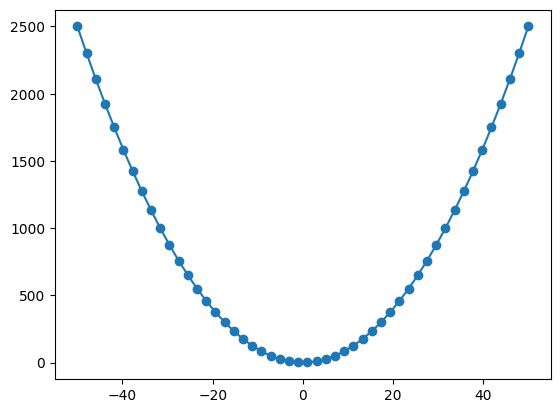

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Artificial generation of the dataset
x = np.linspace(-50, 50, num=50)
y = x**2

plt.plot(x, y, 'o-')

In [30]:
from sklearn.linear_model import LinearRegression

# We need to reshape data before using the model:
x = x.reshape(-1, 1)

# model learning
model = LinearRegression()
model.fit(x, y)

print("The learned function is:")
print(f"f(x) = {model.intercept_} + {model.coef_[0]} * x")

The learned function is:
f(x) = 867.3469387755104 + 5.459196909203282e-15 * x


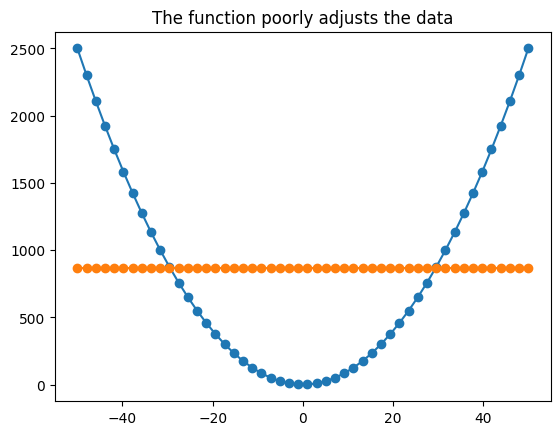

In [22]:
# The function poortly adjust the data:
y_pred = model.predict(x)

fig, ax = plt.subplots()
ax.plot(x, y, 'o-')
ax.plot(x, y_pred, 'o-')
ax.set_title("The function poorly adjusts the data")
plt.show()

What can we do? Well, in this case it should be obvious that the change we need to make is to enable the function to have the form:

$$
g(x) = \beta_0 + \beta_1 x + \beta_2 x^2
$$

And if the GD works correctly we will learn the coefficients 0, 0, 1. The first approach we can think is to throw to the trash the LinearRegressor and to write a "QuadraticRegressor", so we will have this problem solved. However, let's observe that this function $g$ is a linear function, not on the variable $x$ but on the vector $(x, x^2)$. Yes, as you can see, you can improve the behavior of the LinearRegressor model by simply introducing into de dataset a new feature: the feature $x$ squared, and we can train a LinearRegressior model with this new dataset, which will adjust the coefficients $\beta_0, \beta_1, \beta_2$ in order to adjust the function to the dataset:

In [28]:
# Append polynomial features to the dataset
improved_dataset = np.column_stack((x, x**2)) 
improved_dataset

array([[-5.00000000e+01,  2.50000000e+03],
       [-4.79591837e+01,  2.30008330e+03],
       [-4.59183673e+01,  2.10849646e+03],
       [-4.38775510e+01,  1.92523948e+03],
       [-4.18367347e+01,  1.75031237e+03],
       [-3.97959184e+01,  1.58371512e+03],
       [-3.77551020e+01,  1.42544773e+03],
       [-3.57142857e+01,  1.27551020e+03],
       [-3.36734694e+01,  1.13390254e+03],
       [-3.16326531e+01,  1.00062474e+03],
       [-2.95918367e+01,  8.75676801e+02],
       [-2.75510204e+01,  7.59058726e+02],
       [-2.55102041e+01,  6.50770512e+02],
       [-2.34693878e+01,  5.50812162e+02],
       [-2.14285714e+01,  4.59183673e+02],
       [-1.93877551e+01,  3.75885048e+02],
       [-1.73469388e+01,  3.00916285e+02],
       [-1.53061224e+01,  2.34277384e+02],
       [-1.32653061e+01,  1.75968347e+02],
       [-1.12244898e+01,  1.25989171e+02],
       [-9.18367347e+00,  8.43398584e+01],
       [-7.14285714e+00,  5.10204082e+01],
       [-5.10204082e+00,  2.60308205e+01],
       [-3.

In [31]:
# Train the model
model = LinearRegression()
model.fit(improved_dataset, y)

print("The learned function is:")
print(f"g(x) = {model.intercept_} + {model.coef_[0]} * x + {model.coef_[1]} * x**2")

The learned function is:
g(x) = 3.410605131648481e-13 + 2.183678763681313e-15 * x + 1.0 * x**2


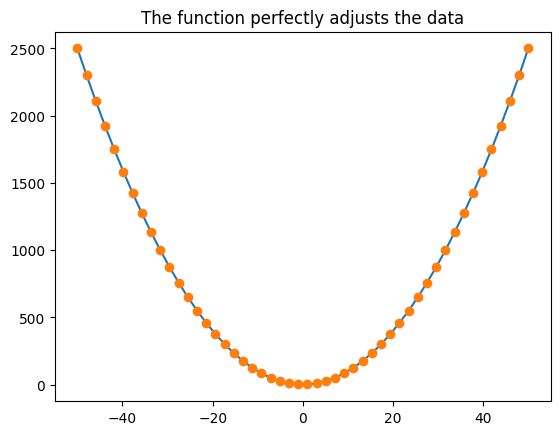

In [ ]:
# The function perfectly adjusts the (sintetic) data

y_pred = model.predict(improved_dataset)

fig, ax = plt.subplots()
ax.plot(x, y, '-')
ax.plot(x, y_pred, 'o')
ax.set_title("The function perfectly adjusts the data")
plt.show()

This was a sintetic example, so the prediction is perfect and the appended polynomial features were easy to think. In other scenarios with real-world data and higher dimensions it will not be so obvios that the append of polynomial features will introduce a significant benefit. Also, polynomial features may suffer from overfitting.